# Implied PD Term Structure

Credit spreads contain forward-looking information about the market's assessment of default probability. By inverting the relationship between observed OAS and expected credit losses, we can extract market-implied probability of default (PD) term structures for each rating bucket.

This notebook builds directly on the two preceding analyses:

- **Notebook 2** established that OAS can be decomposed into systematic components driven by VIX, yield curve slope, and financial conditions
- **Notebook 3** identified four distinct credit market regimes with meaningfully different spread levels and volatility characteristics

The central contribution of this notebook is to calibrate **regime-conditional PD term structures**, separate implied PD curves for each rating bucket under each of the four regimes identified by the HMM. These regime-conditional PD curves serve as the primary input to the CVA estimation framework in Notebook 5.

## Recall: Hazard Rate Framework

Under the constant hazard rate assumption, the cumulative probability of default by time $t$ is:

$$Q(t) = 1 - e^{-\lambda t}$$

where $\lambda$ is the hazard rate (default intensity), representing the instantaneous conditional probability of default per unit time.

The survival probability — the probability of no default up to time $t$ — is:

$$S(t) = e^{-\lambda t}$$

The marginal (unconditional) probability of default between time $t_1$ and $t_2$ is:

$$q(t_1, t_2) = Q(t_2) - Q(t_1) = e^{-\lambda t_1} - e^{-\lambda t_2}$$

The conditional probability of default between time $t_1$ and $t_2$ is:

$$p(t_1, t_2) = \frac{q(t_1, t_2)}{S(t_1)} = \frac{e^{-\lambda t_1} - e^{-\lambda t_2}}{e^{-\lambda t_1}}$$

The relationship between OAS, hazard rate, and loss given default (LGD) under risk-neutral pricing is:

$$OAS \approx \lambda \times LGD$$

Solving for the hazard rate:

$$\lambda = \frac{OAS}{LGD}$$

where $LGD = 1 - RR$ and $RR$ is the recovery rate.

This approximation holds when the OAS is expressed as a continuously compounded spread and default events are independent of interest rates. While simplifying, it provides a tractable and market-consistent framework for extracting implied default intensities from observable spreads.

We assume a constant recovery rate of 40% (LGD = 60%) across all rating buckets. This assumption is consistent with standard CDS market convention, Basel regulatory practice for unsecured corporate exposures, and the reduced-form credit risk literature. While recovery rates vary across issuers and economic conditions, a uniform assumption isolates the effect of regime-dependent OAS variation on implied default probabilities without introducing additional calibration uncertainty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('../data/processed/main_dataset.csv', index_col='date', parse_dates=True)

regimes = pd.read_csv('../data/processed/regime_labels.csv', index_col='date', parse_dates=True)

regime_summary = pd.read_csv('../data/processed/regime_summary.csv', index_col='regime')

trans_matrix = pd.read_csv('../data/processed/transition_matrix.csv', index_col=0)

# merge datasets with regime labels
df = df.join(regimes, how='inner')

print(f"Main dataset: {df.shape}")
print(f"Regime summary: {regime_summary.shape}")
print(f"\nRegime distribution:")
print(df['regime_name'].value_counts())
print(f"\nTransition matrix:")
print(trans_matrix.round(4))

Main dataset: (1325, 15)
Regime summary: (4, 10)

Regime distribution:
regime_name
Normalization          422
Risk-On                393
Macro Tightening       301
Event-Driven Stress    209
Name: count, dtype: int64

Transition matrix:
                     Risk-On  Normalization  Event-Driven Stress  \
Risk-On               0.9918         0.0000               0.0082   
Normalization         0.0000         0.9902               0.0050   
Event-Driven Stress   0.0152         0.0052               0.9748   
Macro Tightening      0.0000         0.0099               0.0000   

                     Macro Tightening  
Risk-On                        0.0000  
Normalization                  0.0048  
Event-Driven Stress            0.0048  
Macro Tightening               0.9901  


## Hazard Rate Calibration

We calibrate hazard rates using the relationship:

$$\lambda = \frac{OAS}{1 - \text{Recovery Rate}} = \frac{OAS}{LGD}$$

where OAS is expressed in decimal form and LGD = 0.60 (recovery rate = 40%). A uniform recovery rate is applied across all rating buckets to isolate the effect of OAS differences on implied PD without introducing additional parameters requiring separate empirical justification.

We calibrate hazard rates at three levels:

1. **Full-sample**: single $\lambda$ per rating bucket using the time-series mean OAS over the entire sample
2. **Regime-conditional**: separate $\lambda$ per rating bucket per regime, using the regime-conditional mean OAS from the HMM output
3. **Time-varying**: rolling 63-day (3-month) mean OAS converted to $\lambda$, producing a daily hazard rate time series for each rating bucket

In [5]:
# Parameters
RR = 0.40
LGD = 1 - RR

oas_cols = {
    'AAA': 'aaa_oas',
    'IG': 'ig_oas',
    'BBB': 'bbb_oas',
    'HY': 'hy_oas',
}

regime_order = [
    'Risk-On',
    'Normalization',
    'Event-Driven Stress',
    'Macro Tightening',
]

# 1. Full-sample hazard rates
print("Full-Sample Hazard Rate Calibration")
print("="*85)
print(f"Recovery Rate: {RR:.0%}  |  "
      f"LGD: {LGD:.0%}")
print(f"\n{'Rating':<8} {'Mean OAS (bps)':>15} "
      f"{'OAS (decimal)':>15} "
      f"{'Hazard Rate λ':>15}"
      f"{'Ann. PD (1Y)':>15}")
print("-"*85)

full_sample_lambda = {}
for rating, col in oas_cols.items():
    mean_oas_bps = df[col].mean()
    mean_oas_decimal = mean_oas_bps / 10000
    lam  = mean_oas_decimal / LGD
    pd_1y = 1 - np.exp(-lam * 1)
    full_sample_lambda[rating] = lam
    print(f"{rating:<8} {mean_oas_bps:>15.2f} "
          f"{mean_oas_decimal:>15.4f} "
          f"{lam:>15.4f} "
          f"{pd_1y:>15.4%}")

# 2. Regime-conditional hazard rates 
print(f"\n\nRegime-Conditional Hazard Rates")
print("="*65)

regime_lambda = {}

for regime in regime_order:
    mask = df['regime_name'] == regime
    regime_lambda[regime] = {}

    print(f"\n{regime} ({mask.sum()} days)")
    print(f"  {'Rating':<8} {'Mean OAS (bps)':>15} "
          f"{'λ':>10} {'Ann. PD (1Y)':>14}")
    print(f"  {'-'*50}")

    for rating, col in oas_cols.items():
        mean_oas_bps = df.loc[mask, col].mean()
        mean_oas_dec = mean_oas_bps / 10000
        lam = mean_oas_dec / LGD
        pd_1y = 1 - np.exp(-lam * 1)
        regime_lambda[regime][rating] = lam

        print(f"  {rating:<8} {mean_oas_bps:>15.2f} "
              f"{lam:>10.4f} {pd_1y:>13.4%}")

Full-Sample Hazard Rate Calibration
Recovery Rate: 40%  |  LGD: 60%

Rating    Mean OAS (bps)   OAS (decimal)   Hazard Rate λ   Ann. PD (1Y)
-------------------------------------------------------------------------------------
AAA                46.25          0.0046          0.0077         0.7679%
IG                107.15          0.0107          0.0179         1.7700%
BBB               133.02          0.0133          0.0222         2.1926%
HY                357.97          0.0358          0.0597         5.7916%


Regime-Conditional Hazard Rates

Risk-On (393 days)
  Rating    Mean OAS (bps)          λ   Ann. PD (1Y)
  --------------------------------------------------
  AAA                40.03     0.0067       0.6650%
  IG                 84.78     0.0141       1.4031%
  BBB               106.05     0.0177       1.7519%
  HY                301.76     0.0503       4.9050%

Normalization (422 days)
  Rating    Mean OAS (bps)          λ   Ann. PD (1Y)
  --------------------------------

**Full-sample implied PDs** follow the expected rating hierarchy: AAA (0.77%), IG (1.77%), BBB (2.19%), and HY (5.79%). These market-implied figures are substantially higher than historical default rates reported by rating agencies. This gap is expected and reflects the fact that OAS contains components beyond expected credit loss, including risk premium and liquidity premium, as documented in the decomposition analysis of Notebook 2. Market-implied PDs should therefore be interpreted as risk-neutral default probabilities rather than real-world estimates.

**Regime-conditional hazard rates** reveal meaningful variation across market environments. For IG, the implied 1-year PD ranges from 1.40% in the Risk-On regime to 2.37% in Macro Tightening — a difference of nearly 100 basis points in probability terms. For HY, the range is wider: 4.91% (Risk-On) to 7.43% (Macro Tightening), reflecting the amplified sensitivity of speculative-grade credit to macro conditions documented throughout the analysis.

**Event-Driven Stress produces lower implied PDs than Macro Tightening** across all rating buckets, consistent with the shorter average duration and lower mean OAS of that regime. This confirms that the market prices sustained macro deterioration more severely than short-lived volatility shocks in terms of implied default intensity.

The monotonic ordering of implied PDs across regimes (Risk-On < Normalization < Event-Driven Stress < Macro Tightening) holds consistently for all four rating buckets, validating the economic interpretation of the HMM regime structure established in Notebook 3.

## PD Term Structure

Using the calibrated regime-conditional hazard rates, we construct PD term structures for maturities of 1, 2, 3, 4, and 5 years. Three quantities are computed for each rating bucket and regime:

- **Cumulative PD**: probability of default by time t, $Q(t) = 1 - e^{-\lambda t}$
- **Survival rate**: probability of no default up to time t, $S(t) = e^{-\lambda t}$
- **Marginal PD**: probability of default between $t-1$ and $t$, $q(t-1, t) = e^{-\lambda(t-1)} - e^{-\lambda t}$

The marginal PD is the key input to CVA computation in Notebook 5, where it weights the expected exposure profile at each time step.

In [6]:
tenors = np.array([1, 2, 3, 4, 5])

def pd_term_structure(lam, tenors):
    """
    Compute PD term structure given hazard rate.
    Returns cumulative PD, survival rate, and marginal PD for each tenor.
    """
    cum_pd = 1 - np.exp(-lam * tenors)
    survival = np.exp(-lam * tenors)
    marginal_pd = np.concatenate([
        [1 - np.exp(-lam * tenors[0])],
        np.exp(-lam * tenors[:-1]) - 
        np.exp(-lam * tenors[1:])
    ])
    return cum_pd, survival, marginal_pd

# Print regime-conditional term structures
for regime in regime_order:
    print(f"\n{'='*65}")
    print(f"  {regime}")
    print(f"{'='*65}")
    print(f"  {'Tenor':<8}", end="")
    for rating in oas_cols:
        print(f"  {rating:>12}", end="")
    print()

    for metric, label in [
        ('cum_pd', 'Cumulative PD (%)'),
        ('survival', 'Survival Rate (%)'),
        ('marginal', 'Marginal PD (%)'),
    ]:
        print(f"\n  {label}")
        print(f"  {'-'*60}")

        # Store term structure for each rating
        ts = {}
        for rating in oas_cols:
            lam = regime_lambda[regime][rating]
            cum, surv, marg = pd_term_structure(
                lam, tenors
            )
            ts[rating] = {
                'cum_pd': cum,
                'survival': surv,
                'marginal': marg,
            }

        for i, t in enumerate(tenors):
            print(f"  {t}Y{'':<6}", end="")
            for rating in oas_cols:
                val = ts[rating][metric][i] * 100
                print(f"  {val:>11.4f}%", end="")
            print()


  Risk-On
  Tenor              AAA            IG           BBB            HY

  Cumulative PD (%)
  ------------------------------------------------------------
  1Y             0.6650%       1.4031%       1.7519%       4.9050%
  2Y             1.3256%       2.7865%       3.4732%       9.5694%
  3Y             1.9818%       4.1505%       5.1643%      14.0049%
  4Y             2.6336%       5.4953%       6.8258%      18.2230%
  5Y             3.2811%       6.8213%       8.4581%      22.2341%

  Survival Rate (%)
  ------------------------------------------------------------
  1Y            99.3350%      98.5969%      98.2481%      95.0950%
  2Y            98.6744%      97.2135%      96.5268%      90.4306%
  3Y            98.0182%      95.8495%      94.8357%      85.9951%
  4Y            97.3664%      94.5047%      93.1742%      81.7770%
  5Y            96.7189%      93.1787%      91.5419%      77.7659%

  Marginal PD (%)
  ------------------------------------------------------------
  

PD term structures are upward sloping across all rating buckets and regimes, consistent with the constant hazard rate assumption under which cumulative default probability increases monotonically with tenor.

**Marginal PDs decline gradually with tenor** across all regimes, reflecting the survivor effect: as weaker credits default over time, the remaining population becomes progressively stronger, reducing the conditional probability of default in later years. This is a standard property of the exponential survival framework.

**Regime separation remains economically meaningful across all horizons.** For IG credit, cumulative 5-year PD ranges from 6.82% in Risk-On to 11.31% in Macro Tightening. For HY, the spread is substantially wider: 22.23% versus 32.04%, confirming the amplified sensitivity of speculative-grade credit to sustained macro deterioration.

**AAA survival rates remain consistently high across all regimes**, ranging from 95.55% to 96.72% at the 5-year horizon. The relatively narrow dispersion confirms that top-tier credit remains comparatively insulated from regime transitions and retains its flight-to-quality characteristics during stress periods.

By contrast, **HY cumulative PD exceeds 30% at the 5-year horizon under Macro Tightening**, reflecting the sustained spread widening and restrictive financial conditions observed during the 2022 tightening cycle. This regime-dependent deterioration in implied default intensity has direct implications for counterparty credit risk and CVA under stressed macro environments, which will be explored in Notebook 5.

We then plot the cumulative PD term structures for each rating bucket across all four regimes on the same chart. This allows direct visual comparison of how 
the implied default curve shifts between market environments. The vertical distance between regime curves at any given tenor represents the additional default 
probability implied by the market under that regime relative to the Risk-On baseline.

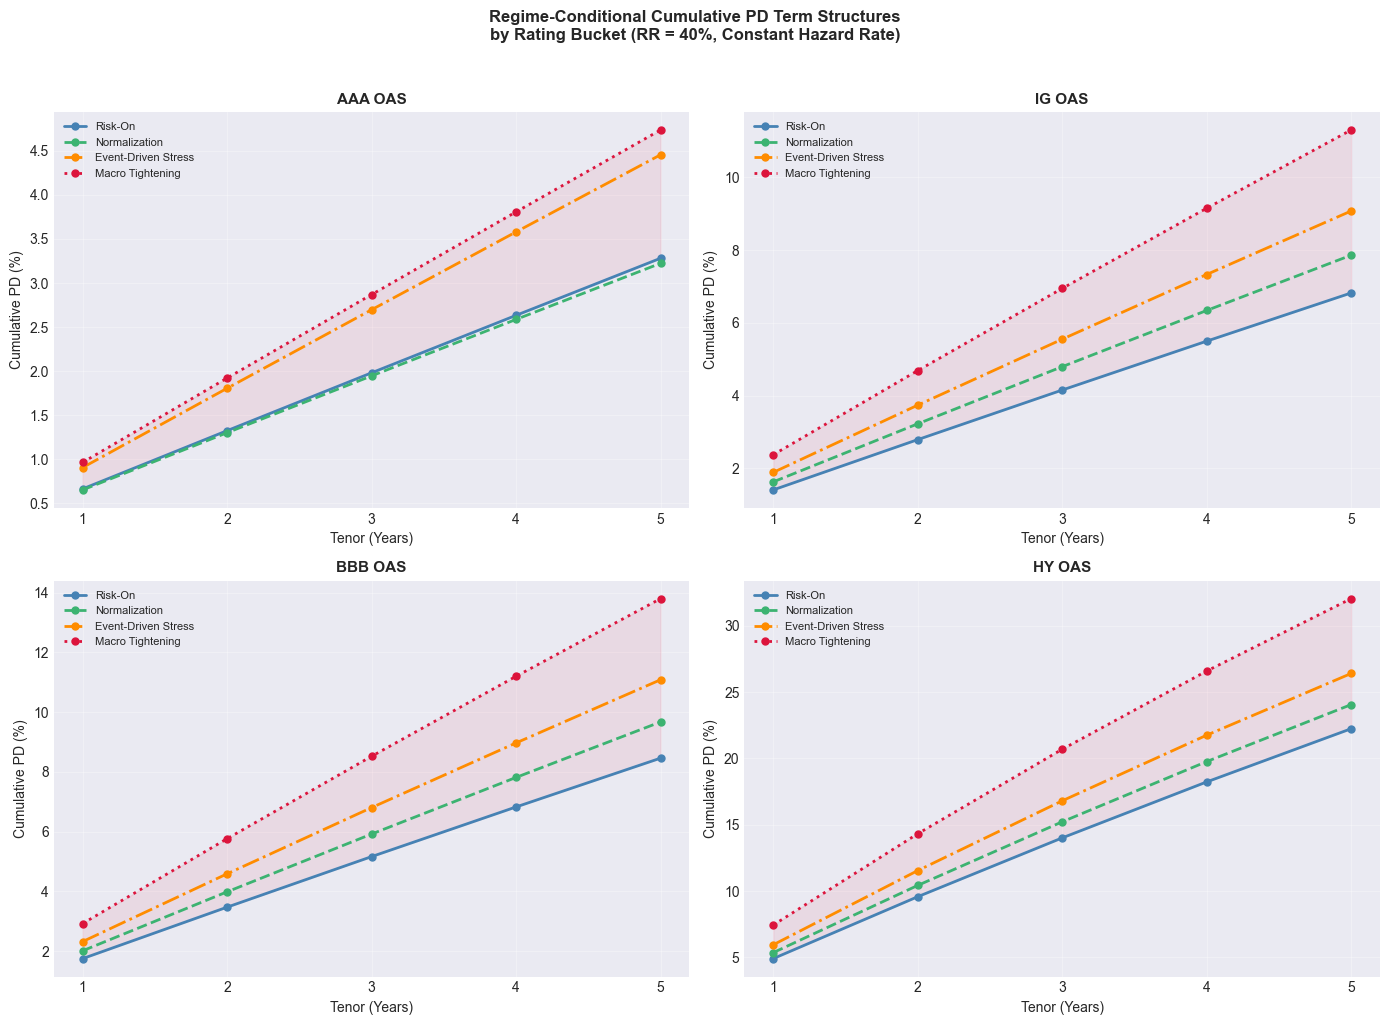

In [8]:
regime_colors_plot = {
    'Risk-On': 'steelblue',
    'Normalization': 'mediumseagreen',
    'Event-Driven Stress': 'darkorange',
    'Macro Tightening': 'crimson',
}
line_styles = {
    'Risk-On': '-',
    'Normalization': '--',
    'Event-Driven Stress': '-.',
    'Macro Tightening': ':',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rating, col) in zip(axes, oas_cols.items()):
    for regime in regime_order:
        lam = regime_lambda[regime][rating]
        cum_pd, _, _ = pd_term_structure(lam, tenors)

        ax.plot(
            tenors,
            cum_pd * 100,
            color=regime_colors_plot[regime],
            linestyle=line_styles[regime],
            linewidth=2.0,
            marker='o',
            markersize=5,
            label=regime
        )

    ax.set_title(f'{rating} OAS',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Tenor (Years)')
    ax.set_ylabel('Cumulative PD (%)')
    ax.set_xticks(tenors)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

    # Add regime shading between Risk-On and Macro Tightening to show amplification
    lam_ro = regime_lambda['Risk-On'][rating]
    lam_mt = regime_lambda['Macro Tightening'][rating]
    pd_ro, _, _ = pd_term_structure(lam_ro, tenors)
    pd_mt, _, _ = pd_term_structure(lam_mt, tenors)

    ax.fill_between(
        tenors,
        pd_ro * 100,
        pd_mt * 100,
        alpha=0.08,
        color='crimson',
        label='Regime amplification'
    )

plt.suptitle(
    'Regime-Conditional Cumulative PD Term Structures\n'
    'by Rating Bucket (RR = 40%, Constant Hazard Rate)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/04_pd_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()

The regime amplification band — shaded between the Risk-On and Macro Tightening curves — widens monotonically with tenor across all rating buckets. This reflects the compounding effect of higher hazard rates over longer horizons: relatively modest differences in short-term default intensity translate into substantially larger cumulative PD gaps at longer maturities.

For **AAA**, the amplification band remains narrow throughout (0.67% to 4.74% at 5Y), confirming that top-tier credit is comparatively insulated from regime transitions. The Risk-On and Normalization curves are nearly indistinguishable at short tenors, indicating limited sensitivity of high-quality credit to moderate changes in market conditions.

For **IG and BBB**, regime separation becomes more pronounced with tenor. At the 5-year horizon, the Macro Tightening cumulative PD exceeds the Risk-On baseline by approximately 4.5 percentage points for IG and 5.3 percentage points for BBB. The ordering Risk-On < Normalization < Event-Driven Stress < Macro Tightening is preserved consistently across all maturities, validating the internal consistency of the regime-conditioned hazard rate calibration.

For **HY**, regime amplification is strongest. The Macro Tightening curve reaches 32.0% cumulative PD at 5 years versus 22.2% under Risk-On, implying a nearly 10 percentage point increase in cumulative default risk attributable solely to regime conditions. This highlights the disproportionate sensitivity of speculative-grade credit to sustained macro deterioration.

The near-linear shape of the curves is a direct consequence of the constant hazard rate assumption. For lower hazard rates, cumulative PD grows approximately linearly with tenor, while the mild concavity visible in HY at longer maturities reflects the nonlinear behavior of the exponential survival function at higher default intensities.

## Time-Varying Hazard Rate

The regime-conditional hazard rates above are static estimates based on average OAS within each regime. In practice, credit conditions evolve continuously over time, even within the same regime. We therefore construct a time-varying hazard rate series to capture the day-to-day evolution of implied default intensity.

For each rating bucket, we compute a rolling 63-day (approximately 3-month) average OAS and convert it into a hazard rate using:

$$\lambda_t = \frac{\overline{OAS}_t^{63d}}{LGD}$$

The 63-day window provides a balance between responsiveness and stability: shorter windows introduce excessive noise, while longer windows may smooth over meaningful regime transitions. The resulting hazard rate series is overlaid with the HMM regime labels from Notebook 3, allowing us to examine how implied default intensity evolves both within regimes and during regime transitions.

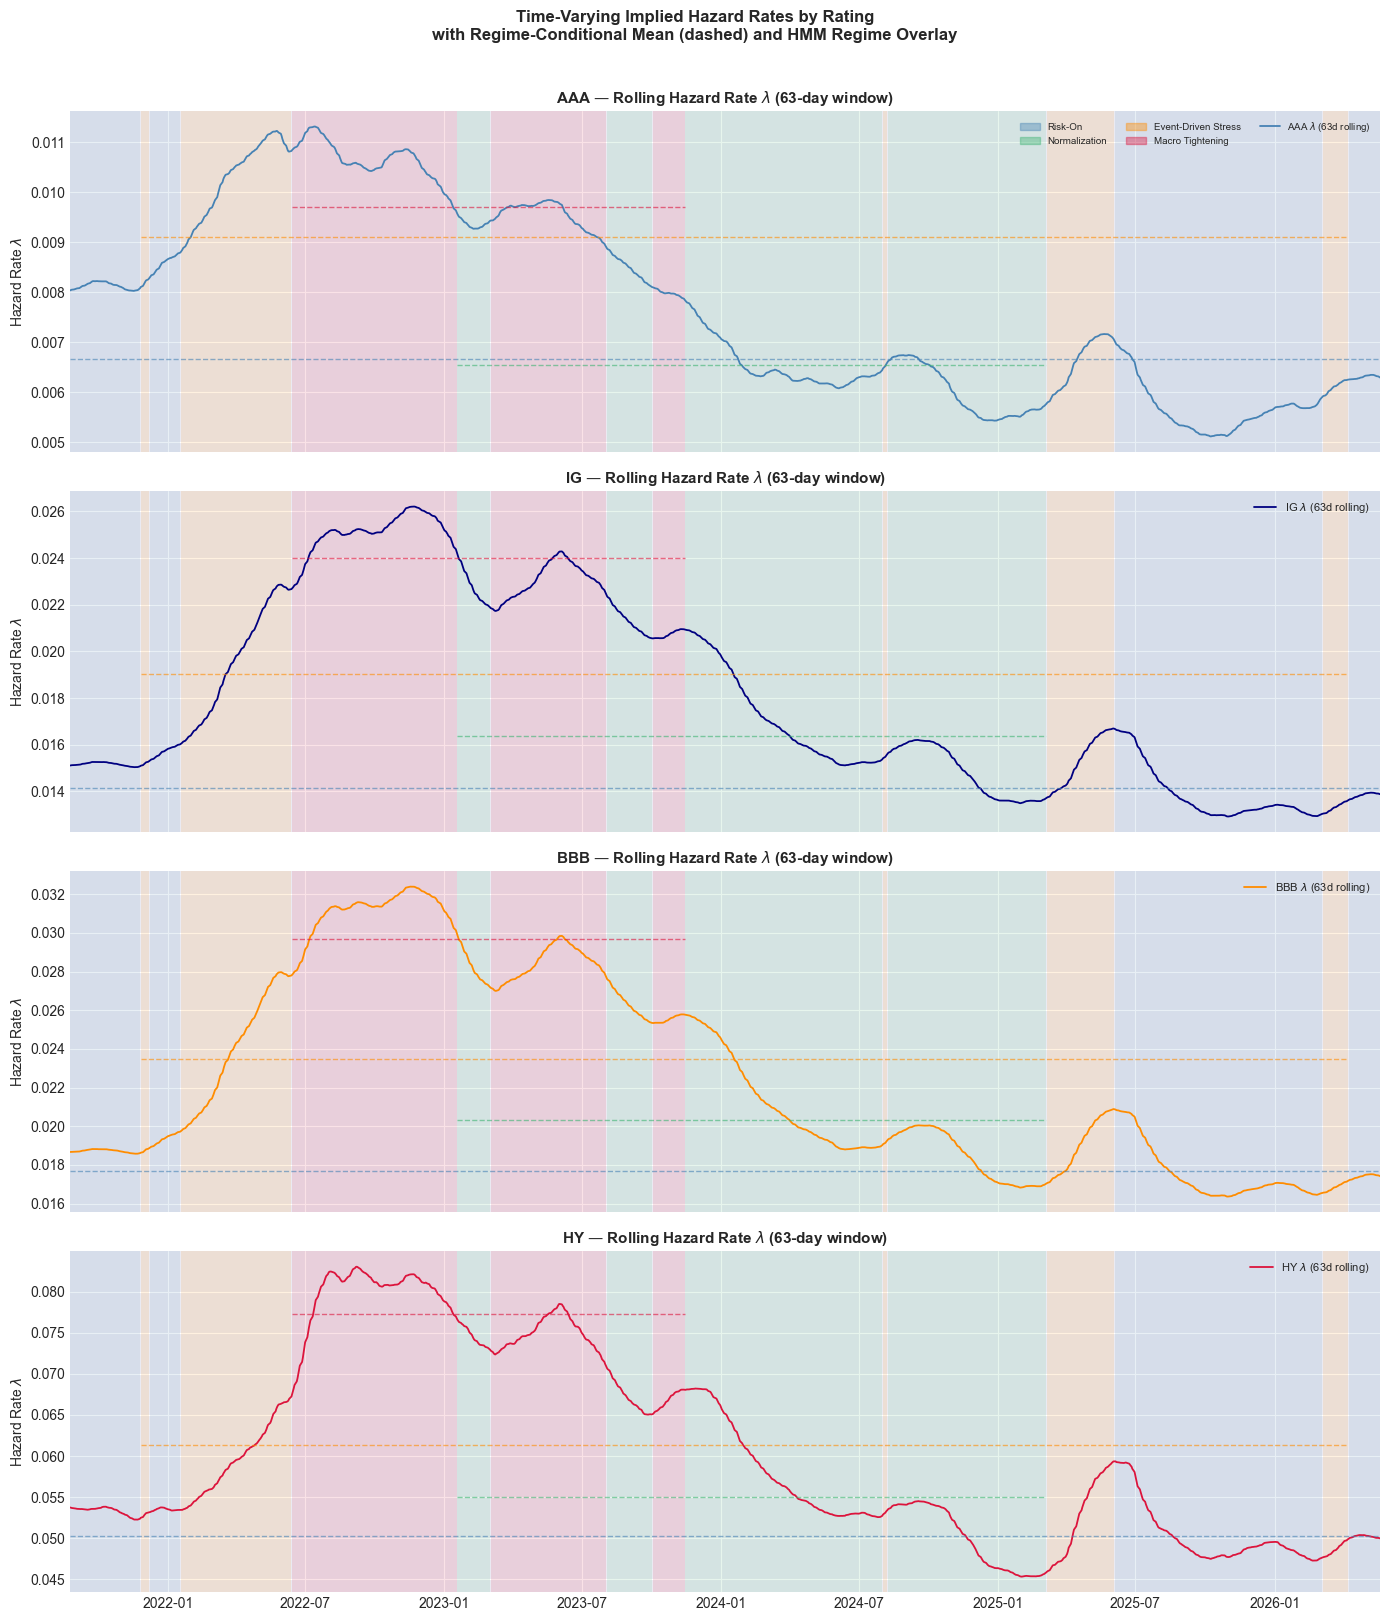

In [ ]:
WINDOW = 63

# Compute rolling hazard rates
rolling_lambda = pd.DataFrame(index=df.index)

for rating, col in oas_cols.items():
    rolling_oas = df[col].rolling(window=WINDOW, min_periods=WINDOW).mean()
    rolling_lambda[rating] = (rolling_oas / 10000) / LGD

# Merge with regime labels
rolling_lambda = rolling_lambda.join(
    df[['regime', 'regime_name']], how='inner'
).dropna()

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

rating_colors = {
    'AAA': 'steelblue',
    'IG': 'navy',
    'BBB': 'darkorange',
    'HY': 'crimson',
}

def shade_regimes_ax(ax, regime_series, regime_colors, alpha=0.12):
    regime_color_map = {
        'Risk-On': 'steelblue',
        'Normalization': 'mediumseagreen',
        'Event-Driven Stress': 'darkorange',
        'Macro Tightening': 'crimson',
    }
    for name, color in regime_color_map.items():
        mask    = (regime_series == name).values
        indices = np.where(mask)[0]
        if len(indices) == 0:
            continue
        breaks = np.where(np.diff(indices) > 1)[0] + 1
        blocks = np.split(indices, breaks)
        for block in blocks:
            start = regime_series.index[block[0]]
            end   = regime_series.index[block[-1]]
            ax.axvspan(start, end,
                       alpha=alpha, color=color,
                       linewidth=0)

for ax, (rating, col) in zip(
    axes, oas_cols.items()
):
    shade_regimes_ax(
        ax,
        rolling_lambda['regime_name'],
        regime_colors_plot
    )

    # Plot rolling lambda
    ax.plot(
        rolling_lambda.index,
        rolling_lambda[rating],
        color=rating_colors[rating],
        linewidth=1.3,
        label=f'{rating} $\lambda$ (63d rolling)'
    )

    # Add regime-conditional mean lines
    for regime in regime_order:
        lam_mean = regime_lambda[regime][rating]
        mask     = (
            rolling_lambda['regime_name'] == regime
        )
        if mask.sum() == 0:
            continue
        start = rolling_lambda.index[mask][0]
        end   = rolling_lambda.index[mask][-1]
        ax.hlines(
            lam_mean,
            xmin=start, xmax=end,
            colors=regime_colors_plot[regime],
            linestyles='--',
            linewidth=1.0,
            alpha=0.6
        )

    ax.set_title(
        f'{rating} — Rolling Hazard Rate $\lambda$ '
        f'(63-day window)',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Hazard Rate $\lambda$')
    ax.set_xlim(
        rolling_lambda.index.min(),
        rolling_lambda.index.max()
    )
    ax.legend(loc='upper right', fontsize=8)

from matplotlib.patches import Patch
regime_patches = [
    Patch(color='steelblue',
          alpha=0.4, label='Risk-On'),
    Patch(color='mediumseagreen',
          alpha=0.4, label='Normalization'),
    Patch(color='darkorange',
          alpha=0.4, label='Event-Driven Stress'),
    Patch(color='crimson',
          alpha=0.4, label='Macro Tightening'),
]
axes[0].legend(
    handles=regime_patches +
    [axes[0].lines[0]],
    loc='upper right', fontsize=7, ncol=3
)

plt.suptitle(
    'Time-Varying Implied Hazard Rates by Rating\n'
    'with Regime-Conditional Mean (dashed) and HMM Regime Overlay',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../data/processed/04_rolling_hazard_rate.png', dpi=150, bbox_inches='tight')
plt.show()

The rolling hazard rate series confirms that implied default intensity evolves dynamically both across and within regimes. Hazard rates rise sharply entering the Macro Tightening period, with the transition from Risk-On beginning in late 2021 and accelerating throughout 2022. IG $\lambda$ peaks near 0.026, while HY $\lambda$ reaches approximately 0.082 — roughly 70% and 60% above their respective Risk-On baselines. The dashed regime-conditional mean lines remain broadly aligned with the rolling estimates, validating the consistency of the static calibration framework.

The March 2023 SVB stress episode appears as a secondary peak in IG, BBB, and HY hazard rates during the broader Normalization regime. Hazard rates briefly re-elevate before resuming their downward trend, illustrating that substantial point-in-time variation can exist even within a stable regime classification. This highlights a key limitation of static regime averages as real-time risk measures.

Hazard rates compress steadily through 2024, reaching sample lows during the Risk-On environment of mid-2024 through early 2025. The decline is most pronounced in HY, where $\lambda$ falls from approximately 0.082 to below 0.050 — a reduction of more than 40% in implied default intensity.

The 2025 tariff shock appears as a short-lived upward spike across all rating buckets during the Event-Driven Stress episode, followed by rapid mean reversion. This behavior is consistent with the short average duration (39.8 days) of the Event-Driven Stress regime identified in Notebook 3.

AAA hazard rates remain comparatively smooth throughout the sample, reflecting the lower volatility and greater stability of top-tier credit spreads. The regime-conditional mean lines for AAA are tightly clustered, consistent with the narrow regime amplification observed earlier in the PD term structure analysis.

Save the regime-conditional hazard rates, PD term structures, and time-varying hazard rate series for use in Notebook 5 (CVA/DVA Estimation).

In [14]:
# Dave regime-conditional hazard rates
lambda_rows = []
for regime in regime_order:
    for rating in oas_cols:
        lambda_rows.append({
            'regime': regime,
            'rating': rating,
            'lambda': regime_lambda[regime][rating],
            'pd_1y':  1 - np.exp(
                -regime_lambda[regime][rating] * 1
            ),
            'pd_2y':  1 - np.exp(
                -regime_lambda[regime][rating] * 2
            ),
            'pd_3y':  1 - np.exp(
                -regime_lambda[regime][rating] * 3
            ),
            'pd_4y':  1 - np.exp(
                -regime_lambda[regime][rating] * 4
            ),
            'pd_5y':  1 - np.exp(
                -regime_lambda[regime][rating] * 5
            ),
        })

lambda_df = pd.DataFrame(lambda_rows)
lambda_df.to_csv('../data/processed/regime_hazard_rates.csv', index=False)
print("Regime-conditional hazard rates")
print(lambda_df.to_string(index=False))

# Save full PD term structures
ts_rows = []
for regime in regime_order:
    for rating in oas_cols:
        lam = regime_lambda[regime][rating]
        cum_pd, survival, marginal = \
            pd_term_structure(lam, tenors)
        for i, t in enumerate(tenors):
            ts_rows.append({
                'regime': regime,
                'rating': rating,
                'tenor': t,
                'hazard_rate': lam,
                'cum_pd': cum_pd[i],
                'survival': survival[i],
                'marginal_pd': marginal[i],
            })

ts_df = pd.DataFrame(ts_rows)
ts_df.to_csv('../data/processed/pd_term_structures.csv', index=False)

# Save rolling hazard rates
rolling_lambda.drop(
    columns=['regime', 'regime_name']
).to_csv('../data/processed/rolling_hazard_rates.csv')

Regime-conditional hazard rates
             regime rating   lambda    pd_1y    pd_2y    pd_3y    pd_4y    pd_5y
            Risk-On    AAA 0.006672 0.006650 0.013256 0.019818 0.026336 0.032811
            Risk-On     IG 0.014130 0.014031 0.027865 0.041505 0.054953 0.068213
            Risk-On    BBB 0.017675 0.017519 0.034732 0.051643 0.068258 0.084581
            Risk-On     HY 0.050293 0.049050 0.095694 0.140049 0.182230 0.222341
      Normalization    AAA 0.006553 0.006532 0.013021 0.019468 0.025873 0.032236
      Normalization     IG 0.016372 0.016239 0.032215 0.047931 0.063391 0.078601
      Normalization    BBB 0.020339 0.020134 0.039862 0.059193 0.078136 0.096696
      Normalization     HY 0.055024 0.053537 0.104208 0.152167 0.197557 0.240518
Event-Driven Stress    AAA 0.009114 0.009073 0.018063 0.026972 0.035800 0.044547
Event-Driven Stress     IG 0.019030 0.018850 0.037344 0.055490 0.073293 0.090761
Event-Driven Stress    BBB 0.023490 0.023216 0.045893 0.068043 0.089679 0.110